# USD/LKR Exchange Rate Forecasting

Forecasting monthly USD/LKR exchange rates using rolling-window validation, comparing Random Forest and XGBoost, with MLflow experiment tracking for reproducibility.

Rolling-window (not a single train/test split) was used deliberately: the dataset spans a 2022 macroeconomic crisis, and a single split hides how a model behaves when the regime it was trained on stops holding. Testing across five expanding windows shows that directly.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import mlflow
import pickle
import json

## Data

In [2]:
df = pd.read_csv('fx_monthly.csv')
print(df.shape)
print(df['date'].min(), 'to', df['date'].max())

(199, 6)
2010-01-01 to 2026-07-01


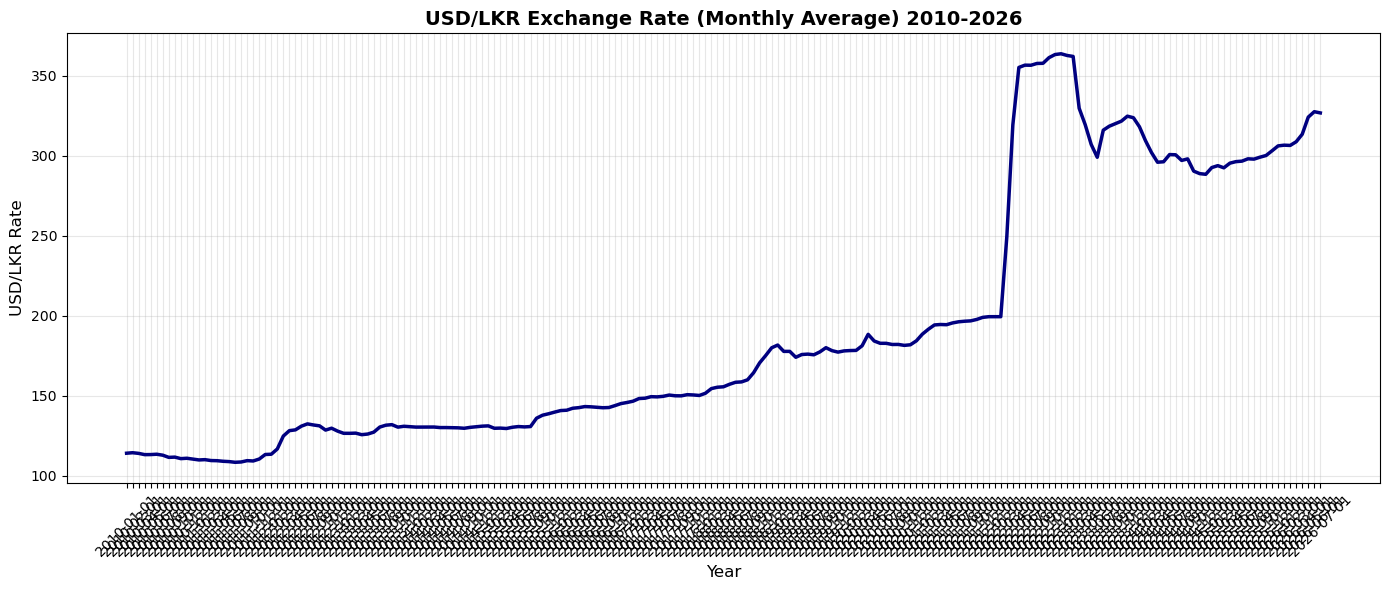

min=108.49  max=363.60  mean=191.57


In [3]:
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['rate_mean'], linewidth=2.5, color='navy')
plt.title('USD/LKR Exchange Rate (Monthly Average) 2010-2026', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('USD/LKR Rate', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"min={df['rate_mean'].min():.2f}  max={df['rate_mean'].max():.2f}  mean={df['rate_mean'].mean():.2f}")

In [4]:
# 7 engineered features: 3 lagged rates, current volatility/range, and lagged volatility
df_enhanced = df[['date', 'rate_mean', 'rate_std', 'rate_max', 'rate_min']].copy()

lags = 3
for lag in range(1, lags + 1):
    df_enhanced[f'lag_rate_{lag}'] = df_enhanced['rate_mean'].shift(lag)

df_enhanced['lag_vol_1'] = df_enhanced['rate_std'].shift(1)

# first few rows have no history to lag from
df_enhanced_clean = df_enhanced.dropna()

feature_names = ['lag_rate_1', 'lag_rate_2', 'lag_rate_3',
                 'rate_std', 'rate_max', 'rate_min', 'lag_vol_1']
X_new = df_enhanced_clean[feature_names].values
y_new = df_enhanced_clean['rate_mean'].values

print(f"usable rows: {len(df_enhanced_clean)} (started with {len(df)})")
print(f"X: {X_new.shape}  y: {y_new.shape}")

usable rows: 196 (started with 199)
X: (196, 7)  y: (196,)


## Rolling window setup

In [5]:
# 5 expanding windows, each testing on the following 12 months
n_windows = 5
test_window_size = 12
data_length = len(X_new)

rolling_windows_enhanced = []

for window_num in range(n_windows):
    test_start = data_length - (n_windows - window_num) * test_window_size
    test_end = test_start + test_window_size

    if test_end > data_length:
        test_end = data_length

    train_end = test_start

    rolling_windows_enhanced.append({
        'window': window_num + 1,
        'train_end': train_end,
        'test_start': test_start,
        'test_end': test_end,
    })

for w in rolling_windows_enhanced:
    print(f"Window {w['window']}: train {w['train_end']} rows, test {w['test_end']-w['test_start']} rows")

Window 1: train 136 rows, test 12 rows
Window 2: train 148 rows, test 12 rows
Window 3: train 160 rows, test 12 rows
Window 4: train 172 rows, test 12 rows
Window 5: train 184 rows, test 12 rows


## Model training

Hyperparameters below were chosen by reasoning about the dataset size (196 rows) rather than a search:

- n_estimators=100: enough trees to average out variance without adding runtime for a dataset this small.
- max_depth=8 for Random Forest and max_depth=5 for XGBoost: shallow enough to avoid memorizing 196 rows, deep enough to capture lag and volatility interactions. XGBoost gets a shallower cap since boosting compounds overfitting across rounds in a way bagging doesn't.
- learning_rate=0.1: XGBoost's standard default, not tuned here, which is itself a limitation (see closing notes).
- subsample=0.8: each tree sees 80% of rows, reducing correlation between trees and mildly regularizing an otherwise small training set.

No grid search or cross-validated tuning was run. These are reasoned defaults, not the result of optimization.

In [6]:
rf_params = {
    'n_estimators': 100,
    'max_depth': 8,
    'min_samples_split': 5,
    'random_state': 42
}

xgb_params = {
    'n_estimators': 100,
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'random_state': 42
}

mlflow.set_experiment("USDLKR-Model-Comparison")

all_results = []

# Random Forest across all windows
for window in rolling_windows_enhanced:
    window_num = window['window']
    train_end, test_start, test_end = window['train_end'], window['test_start'], window['test_end']

    X_train_w = X_new[:train_end]
    y_train_w = y_new[:train_end]
    X_test_w = X_new[test_start:test_end]
    y_test_w = y_new[test_start:test_end]

    with mlflow.start_run(run_name=f"RF-Window{window_num}"):
        for k, v in rf_params.items():
            mlflow.log_param(k, v)
        mlflow.log_param("window", window_num)
        mlflow.log_param("n_features", 7)

        model = RandomForestRegressor(**rf_params)
        model.fit(X_train_w, y_train_w)
        y_pred = model.predict(X_test_w)

        r2 = r2_score(y_test_w, y_pred)
        mae = mean_absolute_error(y_test_w, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_w, y_pred))

        mlflow.log_metric("R2", r2)
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)

        all_results.append({'model': 'RF', 'window': window_num, 'r2': r2, 'mae': mae})
        print(f"RF  window {window_num}: R2={r2:.4f}")

# XGBoost across all windows
for window in rolling_windows_enhanced:
    window_num = window['window']
    train_end, test_start, test_end = window['train_end'], window['test_start'], window['test_end']

    X_train_w = X_new[:train_end]
    y_train_w = y_new[:train_end]
    X_test_w = X_new[test_start:test_end]
    y_test_w = y_new[test_start:test_end]

    with mlflow.start_run(run_name=f"XGB-Window{window_num}"):
        for k, v in xgb_params.items():
            mlflow.log_param(k, v)
        mlflow.log_param("window", window_num)
        mlflow.log_param("n_features", 7)

        model = XGBRegressor(**xgb_params)
        model.fit(X_train_w, y_train_w)
        y_pred = model.predict(X_test_w)

        r2 = r2_score(y_test_w, y_pred)
        mae = mean_absolute_error(y_test_w, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_w, y_pred))

        mlflow.log_metric("R2", r2)
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)

        all_results.append({'model': 'XGB', 'window': window_num, 'r2': r2, 'mae': mae})
        print(f"XGB window {window_num}: R2={r2:.4f}")

2026/09/18 16:29:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/18 16:29:47 INFO mlflow.store.db.utils: Updating database tables
2026/09/18 16:29:47 INFO mlflow.tracking.fluent: Experiment with name 'USDLKR-Model-Comparison' does not exist. Creating a new experiment.


RF  window 1: R2=-0.7060
RF  window 2: R2=-0.5999
RF  window 3: R2=-0.0187
RF  window 4: R2=-0.5933
RF  window 5: R2=0.8304
XGB window 1: R2=-0.6638
XGB window 2: R2=0.2937
XGB window 3: R2=0.5011
XGB window 4: R2=-0.2061
XGB window 5: R2=0.8821


### Per-window results

| Window | Random Forest R² | XGBoost R² |
|---|---|---|
| 1 | -0.7060 | -0.6638 |
| 2 | -0.5999 | 0.2937 |
| 3 | -0.0187 | 0.5011 |
| 4 | -0.5933 | -0.2061 |
| 5 | 0.8304 | 0.8821 |

XGBoost is positive in 3 of 5 windows; Random Forest is positive in only 1 of 5. Both struggle most on Window 1, which has the least training history and no exposure to the 2022 crisis yet. This is the actual basis for preferring XGBoost: not just its higher Window 5 score, but its consistency across most of the timeline.

## Best model and artifacts

In [7]:
window_5 = rolling_windows_enhanced[4]
train_end = window_5['train_end']
test_start = window_5['test_start']
test_end = window_5['test_end']

X_train_best = X_new[:train_end]
y_train_best = y_new[:train_end]
X_test_best = X_new[test_start:test_end]
y_test_best = y_new[test_start:test_end]

best_model = XGBRegressor(**xgb_params)
best_model.fit(X_train_best, y_train_best)

y_pred_best = best_model.predict(X_test_best)

r2_best = r2_score(y_test_best, y_pred_best)
mae_best = mean_absolute_error(y_test_best, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test_best, y_pred_best))

print(f"train: {len(X_train_best)}  test: {len(X_test_best)}")
print(f"R2: {r2_best:.4f}  MAE: {mae_best:.4f}  RMSE: {rmse_best:.4f}")

train: 184  test: 12
R2: 0.8821  MAE: 2.9594  RMSE: 3.5016


### Naive baseline check

lag_rate_1 alone accounts for 93.7% of feature importance (see below), so the natural question is whether the trained model actually beats simply forecasting "next month = this month's rate."

In [8]:
naive_pred = X_test_best[:, feature_names.index('lag_rate_1')]

naive_mae = mean_absolute_error(y_test_best, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test_best, naive_pred))
naive_r2 = r2_score(y_test_best, naive_pred)

print("naive (predict next month = this month's rate):")
print(f"  MAE={naive_mae:.4f}  RMSE={naive_rmse:.4f}  R2={naive_r2:.4f}")
print("xgboost (window 5):")
print(f"  MAE={mae_best:.4f}  RMSE={rmse_best:.4f}  R2={r2_best:.4f}")

mae_gap_pct = (mae_best - naive_mae) / naive_mae * 100
rmse_gap_pct = (naive_rmse - rmse_best) / naive_rmse * 100
print(f"\nmodel vs. naive: MAE {mae_gap_pct:+.1f}% (positive = model worse), "
      f"RMSE {rmse_gap_pct:+.1f}% (positive = model better)")
print("the model trades typical-case accuracy for fewer large misses, not a clean win either way")

naive (predict next month = this month's rate):
  MAE=2.5752  RMSE=3.8134  R2=0.8602
xgboost (window 5):
  MAE=2.9594  RMSE=3.5016  R2=0.8821

model vs. naive: MAE +14.9% (positive = model worse), RMSE +8.2% (positive = model better)
the model trades typical-case accuracy for fewer large misses, not a clean win either way


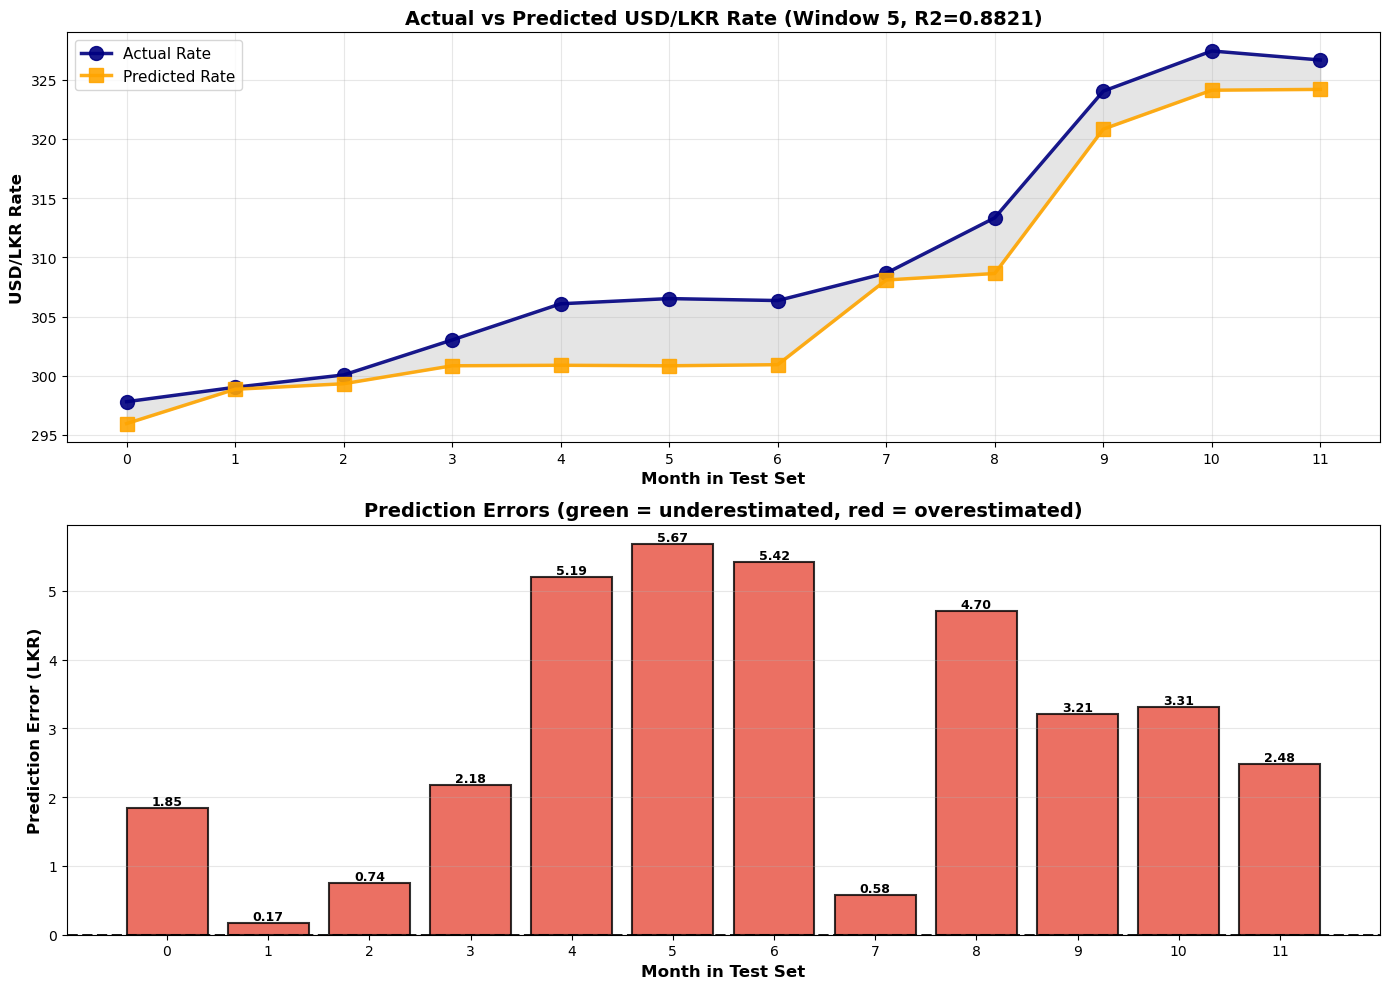

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax1 = axes[0]
test_indices = np.arange(len(y_test_best))
ax1.plot(test_indices, y_test_best, 'o-', linewidth=2.5, markersize=10,
         label='Actual Rate', color='navy', alpha=0.9)
ax1.plot(test_indices, y_pred_best, 's-', linewidth=2.5, markersize=10,
         label='Predicted Rate', color='orange', alpha=0.9)
ax1.fill_between(test_indices, y_test_best, y_pred_best, alpha=0.2, color='gray')
ax1.set_xlabel('Month in Test Set', fontsize=12, fontweight='bold')
ax1.set_ylabel('USD/LKR Rate', fontsize=12, fontweight='bold')
ax1.set_title(f'Actual vs Predicted USD/LKR Rate (Window 5, R2={r2_best:.4f})',
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(test_indices)

ax2 = axes[1]
errors = y_test_best - y_pred_best
colors = ['#2ecc71' if e < 0 else '#e74c3c' for e in errors]
bars = ax2.bar(test_indices, errors, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax2.set_xlabel('Month in Test Set', fontsize=12, fontweight='bold')
ax2.set_ylabel('Prediction Error (LKR)', fontsize=12, fontweight='bold')
ax2.set_title('Prediction Errors (green = underestimated, red = overestimated)',
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(test_indices)

for bar, error in zip(bars, errors):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{error:.2f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('prediction_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

   Feature  Importance  Importance %
lag_rate_1    0.937381     93.738113
  rate_max    0.025955      2.595491
lag_rate_3    0.020652      2.065245
  rate_min    0.013740      1.374031
lag_rate_2    0.002208      0.220781
 lag_vol_1    0.000037      0.003695
  rate_std    0.000026      0.002639


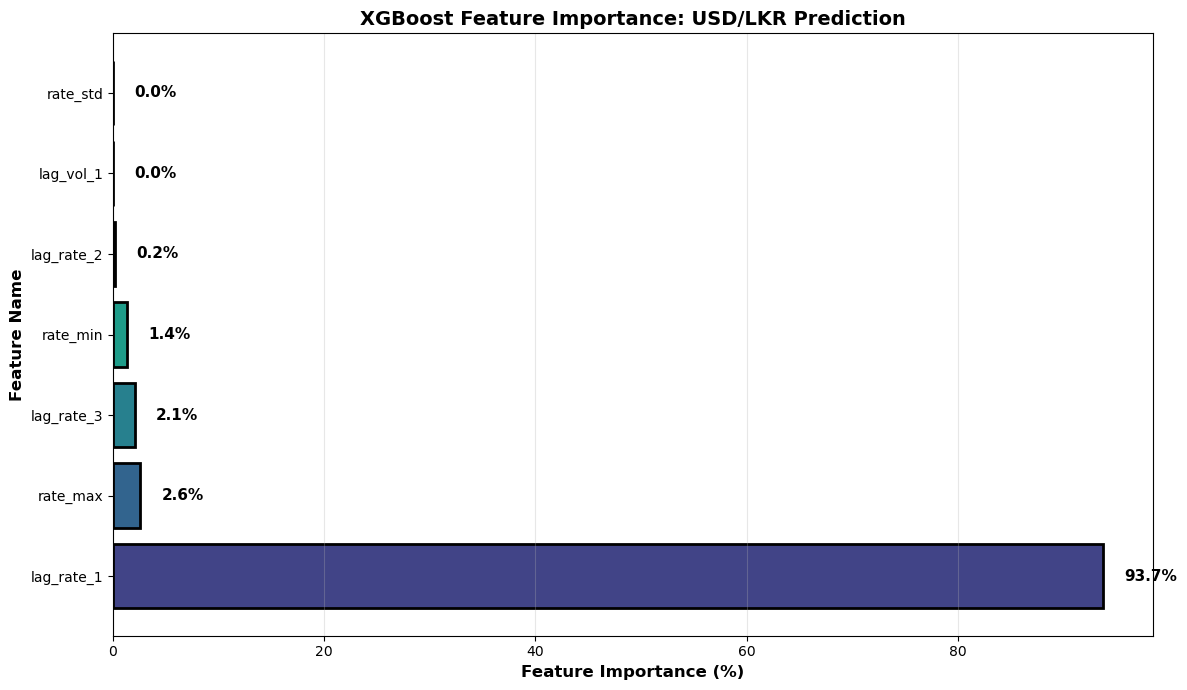

In [10]:
importance_scores = best_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores,
    'Importance %': (importance_scores / importance_scores.sum()) * 100
}).sort_values('Importance', ascending=False)

print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(importance_df)))
bars = ax.barh(importance_df['Feature'], importance_df['Importance %'],
                color=colors, edgecolor='black', linewidth=2)

ax.set_xlabel('Feature Importance (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature Name', fontsize=12, fontweight='bold')
ax.set_title('XGBoost Feature Importance: USD/LKR Prediction', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for i, (feat, imp) in enumerate(zip(importance_df['Feature'], importance_df['Importance %'])):
    ax.text(imp + 2, i, f'{imp:.1f}%', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
model_path = 'xgboost_window5_best.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

metadata = {
    'model_type': 'XGBoost',
    'window': 5,
    'feature_names': feature_names,
    'feature_importance': dict(zip(feature_names, importance_scores.tolist())),
    'model_performance': {
        'R2': float(r2_best),
        'MAE': float(mae_best),
        'RMSE': float(rmse_best)
    },
    'naive_baseline': {
        'MAE': float(naive_mae),
        'RMSE': float(naive_rmse),
        'R2': float(naive_r2)
    },
    'hyperparameters': xgb_params,
    'training_samples': int(len(X_train_best)),
    'test_samples': int(len(X_test_best)),
    'data_period': '2010-2026 (196 months usable after feature engineering)',
    'includes_crisis': True,
    'crisis_period': '2022',
    'created_date': pd.Timestamp.now().isoformat()
}

metadata_path = 'model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"saved {model_path} ({len(pickle.dumps(best_model))/1024:.1f} KB) and {metadata_path}")

saved xgboost_window5_best.pkl (156.6 KB) and model_metadata.json


In [12]:
with mlflow.start_run(run_name="XGBoost-Window5-Best"):

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("window", 5)
    for k, v in xgb_params.items():
        mlflow.log_param(k, v)
    mlflow.log_param("n_features", len(feature_names))
    mlflow.log_param("training_samples", len(X_train_best))
    mlflow.log_param("test_samples", len(X_test_best))

    mlflow.log_metric("R2", r2_best)
    mlflow.log_metric("MAE", mae_best)
    mlflow.log_metric("RMSE", rmse_best)
    mlflow.log_metric("naive_MAE", naive_mae)
    mlflow.log_metric("naive_RMSE", naive_rmse)

    for feat, imp in zip(feature_names, importance_scores):
        mlflow.log_metric(f"importance_{feat}", float(imp))

    mlflow.log_artifact("prediction_visualization.png")
    mlflow.log_artifact("feature_importance.png")
    mlflow.log_artifact(model_path)
    mlflow.log_artifact(metadata_path)

    top_feat = importance_df.iloc[0]
    description = f"""Best model: XGBoost, Window 5 (of 5 rolling windows)

R2 = {r2_best:.4f}, MAE = {mae_best:.4f} LKR, RMSE = {rmse_best:.4f}
Naive baseline (predict = previous month): MAE = {naive_mae:.4f}, RMSE = {naive_rmse:.4f}, R2 = {naive_r2:.4f}

Training: {len(X_train_best)} months (2010-2025, includes 2022 crisis)
Test: {len(X_test_best)} months (2026, post-crisis)

Top feature: {top_feat['Feature']} ({top_feat['Importance %']:.1f}% importance)
Full per-window R2 for both models is in the notebook; this run reflects the strongest window, not the average.
"""
    mlflow.log_text(description, "best_model_report.txt")

    mlflow.set_tag("selected_as_best", "true")
    mlflow.set_tag("data_period", "2010-2026")
    mlflow.set_tag("includes_crisis", "yes")

print("logged best-model run to mlflow")

logged best-model run to mlflow


## Limitations

- **Small test windows.** Each fold tests on only 12 months, so R² and RMSE are sensitive to a handful of points. Window 5's R² = 0.88 could look meaningfully different with a slightly different cutoff.
- **No hyperparameter tuning.** Parameters were chosen by reasoning (above), not by grid or Bayesian search. A tuned model might close or widen the naive-baseline gap.
- **Single crisis, single country.** The 2022 structural break is the only regime shift in this data. Whether XGBoost's advantage generalizes to a different kind of shock (e.g. a gradual depreciation rather than a sudden spike) is untested.
- **Not a clean win over doing nothing.** The naive baseline (previous month's rate) has a lower MAE than the trained model, though the model has a lower RMSE. The added complexity of a trained model is only worth it if avoiding large misses matters more than typical-case accuracy for the use case. That trade-off isn't resolved here, it's disclosed.